# 10 minutes to pandas

In [1]:
import pandas as pd
import numpy as np 

s = pd.Series([1,3,5 , np.nan, 6,8])
print(s)

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64


In [2]:
%pip install pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Basic data structures in pandas
pandas provides two types of classes for handling data:

Series: a one-dimensional labeled array holding data of any type
such as integers, strings, Python objects etc.

DataFrame: a two-dimensional data structure that holds data like a two-dimension array or a table with rows and columns.

# Object creation

In [3]:
dates = pd.date_range("20130101", periods = 6)
print(dates)

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[us]', freq='D')


In [4]:
df = pd.DataFrame(np.random.randn(6,4), index = dates, columns = list("ABCD"))
print(df)

                   A         B         C         D
2013-01-01 -0.658958  0.472353 -0.752247 -0.591614
2013-01-02 -1.086836 -1.136666 -1.218610 -0.762917
2013-01-03  0.526948  0.690325  1.181813  0.362642
2013-01-04  0.184531  1.656280  1.032703 -2.961430
2013-01-05 -0.759444  0.070021 -0.034663  1.177763
2013-01-06 -0.064200  0.705657 -0.000524 -0.123031


In [5]:
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B" : pd.Timestamp("20230102"),
        "C" : pd.Series(1, index = list(range(4)), dtype="float32"),
        "D" : np.array([3] * 4, dtype="int32"),
        "E" : pd.Categorical(["test", "train", "test", "train"]),
        "F" : "foo",
    }
)
print(df2)

     A          B    C  D      E    F
0  1.0 2023-01-02  1.0  3   test  foo
1  1.0 2023-01-02  1.0  3  train  foo
2  1.0 2023-01-02  1.0  3   test  foo
3  1.0 2023-01-02  1.0  3  train  foo


In [6]:
df2.dtypes

A           float64
B    datetime64[us]
C           float32
D             int32
E          category
F               str
dtype: object

# Viewing data
Use DataFrame.head() and DataFrame.tail() to view the top and bottom rows of the frame respectively:

In [7]:
df.head()

,A,B,C,D
2013-01-01,-0.658958,0.472353,-0.752247,-0.591614
2013-01-02,-1.086836,-1.136666,-1.218610,-0.762917
2013-01-03,0.526948,0.690325,1.181813,0.362642
2013-01-04,0.184531,1.656280,1.032703,-2.961430
2013-01-05,-0.759444,0.070021,-0.034663,1.177763


In [8]:
df.tail(3) # bottom 3 rows

,A,B,C,D
2013-01-04,0.184531,1.656280,1.032703,-2.961430
2013-01-05,-0.759444,0.070021,-0.034663,1.177763
2013-01-06,-0.064200,0.705657,-0.000524,-0.123031


In [9]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[us]', freq='D')

In [10]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='str')

In [11]:
df.to_numpy()

array([[-6.58958459e-01,  4.72353344e-01, -7.52247305e-01,
        -5.91614273e-01],
       [-1.08683650e+00, -1.13666619e+00, -1.21861038e+00,
        -7.62917301e-01],
       [ 5.26947982e-01,  6.90324689e-01,  1.18181323e+00,
         3.62641775e-01],
       [ 1.84530518e-01,  1.65627951e+00,  1.03270254e+00,
        -2.96142957e+00],
       [-7.59444329e-01,  7.00207489e-02, -3.46633616e-02,
         1.17776265e+00],
       [-6.42000143e-02,  7.05657359e-01, -5.23934276e-04,
        -1.23030616e-01]])


NOTE: 
NumPy arrays have one dtype for the entire array while pandas DataFrames have one dtype per column. When you call DataFrame.to_numpy(), pandas will find the NumPy dtype that can hold all of the dtypes in the DataFrame. If the common data type is object, DataFrame.to_numpy() will require copying data.

In [12]:
df2.dtypes


A           float64
B    datetime64[us]
C           float32
D             int32
E          category
F               str
dtype: object

In [13]:
df2.to_numpy()

array([[1.0, Timestamp('2023-01-02 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2023-01-02 00:00:00'), 1.0, 3, 'train', 'foo'],
       [1.0, Timestamp('2023-01-02 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2023-01-02 00:00:00'), 1.0, 3, 'train', 'foo']],
      dtype=object)

In [14]:
# NOTE: describe() shows a quick statistic summary of ur data:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,-0.309660,0.409662,0.034745,-0.483098
std,0.621724,0.919876,0.949526,1.402539
min,-1.086836,-1.136666,-1.218610,-2.961430
25%,-0.734323,0.170604,-0.572851,-0.720092
50%,-0.361579,0.581339,-0.017594,-0.357322
75%,0.122348,0.701824,0.774396,0.241224
max,0.526948,1.656280,1.181813,1.177763


In [15]:
#Transposing your data:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,-0.658958,-1.086836,0.526948,0.184531,-0.759444,-0.064200
B,0.472353,-1.136666,0.690325,1.656280,0.070021,0.705657
C,-0.752247,-1.218610,1.181813,1.032703,-0.034663,-0.000524
D,-0.591614,-0.762917,0.362642,-2.961430,1.177763,-0.123031


In [16]:
# DataFrame.sort_index() sorts by an axis:
df.sort_index(axis = 1 ,  ascending = False)

,D,C,B,A
2013-01-01,-0.591614,-0.752247,0.472353,-0.658958
2013-01-02,-0.762917,-1.218610,-1.136666,-1.086836
2013-01-03,0.362642,1.181813,0.690325,0.526948
2013-01-04,-2.961430,1.032703,1.656280,0.184531
2013-01-05,1.177763,-0.034663,0.070021,-0.759444
2013-01-06,-0.123031,-0.000524,0.705657,-0.064200


In [17]:
#DataFrame.sort_values() sorts by values:
df.sort_values(by = "B")

,A,B,C,D
2013-01-02,-1.086836,-1.136666,-1.218610,-0.762917
2013-01-05,-0.759444,0.070021,-0.034663,1.177763
2013-01-01,-0.658958,0.472353,-0.752247,-0.591614
2013-01-03,0.526948,0.690325,1.181813,0.362642
2013-01-06,-0.064200,0.705657,-0.000524,-0.123031
2013-01-04,0.184531,1.656280,1.032703,-2.961430


 # Selection
 While standard Python / NumPy expressions for selecting and setting are intuitive and come in handy for interactive work,
 for production code, we recommend the optimized pandas data access methods, 
 DataFrame.at(), DataFrame.iat(), DataFrame.loc() and DataFrame.iloc(). 

In [18]:
df["A"]

2013-01-01   -0.658958
2013-01-02   -1.086836
2013-01-03    0.526948
2013-01-04    0.184531
2013-01-05   -0.759444
2013-01-06   -0.064200
Freq: D, Name: A, dtype: float64

In [19]:
df.A

2013-01-01   -0.658958
2013-01-02   -1.086836
2013-01-03    0.526948
2013-01-04    0.184531
2013-01-05   -0.759444
2013-01-06   -0.064200
Freq: D, Name: A, dtype: float64

In [20]:
df[["B", "A"]]

,B,A
2013-01-01,0.472353,-0.658958
2013-01-02,-1.136666,-1.086836
2013-01-03,0.690325,0.526948
2013-01-04,1.656280,0.184531
2013-01-05,0.070021,-0.759444
2013-01-06,0.705657,-0.064200


In [21]:
df[0:3]


,A,B,C,D
2013-01-01,-0.658958,0.472353,-0.752247,-0.591614
2013-01-02,-1.086836,-1.136666,-1.218610,-0.762917
2013-01-03,0.526948,0.690325,1.181813,0.362642


In [22]:
df["20130102":"20130104"]

,A,B,C,D
2013-01-02,-1.086836,-1.136666,-1.218610,-0.762917
2013-01-03,0.526948,0.690325,1.181813,0.362642
2013-01-04,0.184531,1.656280,1.032703,-2.961430


# Selection by label
See more in Selection by Label using DataFrame.loc() or DataFrame.at().

In [23]:
#Selecting a row matching a label:
df.loc[dates[0]]

A   -0.658958
B    0.472353
C   -0.752247
D   -0.591614
Name: 2013-01-01 00:00:00, dtype: float64

In [24]:
#Selecting all rows (:) with a select column labels:
df.loc[:,["A", "B"]]

,A,B
2013-01-01,-0.658958,0.472353
2013-01-02,-1.086836,-1.136666
2013-01-03,0.526948,0.690325
2013-01-04,0.184531,1.656280
2013-01-05,-0.759444,0.070021
2013-01-06,-0.064200,0.705657


In [25]:
#For label slicing, both endpoints are included:
df.loc["20130102":"20130104", ["A", "B"]]

,A,B
2013-01-02,-1.086836,-1.136666
2013-01-03,0.526948,0.690325
2013-01-04,0.184531,1.656280


In [26]:
#Selecting a single row and column label returns a scalar:
df.loc[dates[0], "A"]

np.float64(-0.6589584590205113)

In [27]:
#For getting fast access to a scalar (equivalent to the prior method):
df.at[dates[0], "A"]

np.float64(-0.6589584590205113)

# **Selection by position**
See more in Selection by Position using DataFrame.iloc() or DataFrame.iat().

In [28]:
#Select via the position of the passed integers:
df.iloc[3]

A    0.184531
B    1.656280
C    1.032703
D   -2.961430
Name: 2013-01-04 00:00:00, dtype: float64

In [29]:
#Integer slices acts similar to NumPy/Python:
df.iloc[3:5, 0:2]

,A,B
2013-01-04,0.184531,1.656280
2013-01-05,-0.759444,0.070021


In [30]:
#Lists of integer position locations:
df.iloc[[1,2,4],[0,2]]

,A,C
2013-01-02,-1.086836,-1.218610
2013-01-03,0.526948,1.181813
2013-01-05,-0.759444,-0.034663


In [31]:
#For slicing rows explicitly:[37]
df.iloc[1:3,:]

,A,B,C,D
2013-01-02,-1.086836,-1.136666,-1.218610,-0.762917
2013-01-03,0.526948,0.690325,1.181813,0.362642


In [32]:
#For slicing columns explicitly:
df.iloc[:,1:3]

,B,C
2013-01-01,0.472353,-0.752247
2013-01-02,-1.136666,-1.218610
2013-01-03,0.690325,1.181813
2013-01-04,1.656280,1.032703
2013-01-05,0.070021,-0.034663
2013-01-06,0.705657,-0.000524


In [33]:
#For getting a value explicitly:
df.iloc[1,1]

np.float64(-1.1366661931929953)

In [34]:
#For getting fast access to a scalar(equivalent to the prior method):
df.iat[1,1]

np.float64(-1.1366661931929953)

# Boolean indexing

In [35]:
#Select rows where df.A is greater than 0.
df[df.A > 0]

,A,B,C,D
2013-01-03,0.526948,0.690325,1.181813,0.362642
2013-01-04,0.184531,1.656280,1.032703,-2.961430


In [36]:
#Selecting values from a DataFrame where a boolean condition is met:
df[df > 0]

,A,B,C,D
2013-01-01,NaN,0.472353,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN
2013-01-03,0.526948,0.690325,1.181813,0.362642
2013-01-04,0.184531,1.656280,1.032703,NaN
2013-01-05,NaN,0.070021,NaN,1.177763
2013-01-06,NaN,0.705657,NaN,NaN


In [37]:
#Using isin() method for filtering:
df2 = df.copy()
df2["E"] = ["one","one", "two", "three", "four", "three"]
print(df2)
df2[df2["E"].isin(["two", "four"])]

                   A         B         C         D      E
2013-01-01 -0.658958  0.472353 -0.752247 -0.591614    one
2013-01-02 -1.086836 -1.136666 -1.218610 -0.762917    one
2013-01-03  0.526948  0.690325  1.181813  0.362642    two
2013-01-04  0.184531  1.656280  1.032703 -2.961430  three
2013-01-05 -0.759444  0.070021 -0.034663  1.177763   four
2013-01-06 -0.064200  0.705657 -0.000524 -0.123031  three


,A,B,C,D,E
2013-01-03,0.526948,0.690325,1.181813,0.362642,two
2013-01-05,-0.759444,0.070021,-0.034663,1.177763,four


# Setting
Setting a new column automatically aligns the data by the indexes:

In [38]:
s1 = pd.Series(
   [1, 2, 3, 4, 5, 6],
   index=pd.date_range("20130102", periods=6))
print(s1)
df["F"] = s1

2013-01-02    1
2013-01-03    2
2013-01-04    3
2013-01-05    4
2013-01-06    5
2013-01-07    6
Freq: D, dtype: int64


In [39]:
#Setting values by label:
df.at[dates[0],"A"] = 0
#Setting values by position:
df.iat[0, 1] = 0
#Setting by assigning with a NumPy array:
df.loc[:, "D"] = np.array([5] * len(df))
#The result of the prior setting operations:
print(df)

                   A         B         C    D    F
2013-01-01  0.000000  0.000000 -0.752247  5.0  NaN
2013-01-02 -1.086836 -1.136666 -1.218610  5.0  1.0
2013-01-03  0.526948  0.690325  1.181813  5.0  2.0
2013-01-04  0.184531  1.656280  1.032703  5.0  3.0
2013-01-05 -0.759444  0.070021 -0.034663  5.0  4.0
2013-01-06 -0.064200  0.705657 -0.000524  5.0  5.0


In [40]:
#A "where" operation with setting:
df2 = df.copy()
df2[df2> 0] = -df2
print(df2)

                   A         B         C    D    F
2013-01-01  0.000000  0.000000 -0.752247 -5.0  NaN
2013-01-02 -1.086836 -1.136666 -1.218610 -5.0 -1.0
2013-01-03 -0.526948 -0.690325 -1.181813 -5.0 -2.0
2013-01-04 -0.184531 -1.656280 -1.032703 -5.0 -3.0
2013-01-05 -0.759444 -0.070021 -0.034663 -5.0 -4.0
2013-01-06 -0.064200 -0.705657 -0.000524 -5.0 -5.0


# Missing data
For NumPy data types, np.nan represents missing data. It is by default not included in computations. See the Missing Data section.
Reindexing allows you to change/add/delete the index on a specified axis. This returns a copy of the data:

In [41]:
df1 = df.reindex(index = dates[0:4], columns = list(df.columns) + ["E"])
df1.loc[dates[0] : dates[1], "E"] = 1
print(df1)

                   A         B         C    D    F    E
2013-01-01  0.000000  0.000000 -0.752247  5.0  NaN  1.0
2013-01-02 -1.086836 -1.136666 -1.218610  5.0  1.0  1.0
2013-01-03  0.526948  0.690325  1.181813  5.0  2.0  NaN
2013-01-04  0.184531  1.656280  1.032703  5.0  3.0  NaN


In [42]:
#DataFrame.dropna() drops any rows that have missing data:
df1.dropna(how = "any")

,A,B,C,D,F,E
2013-01-02,-1.086836,-1.136666,-1.21861,5.0,1.0,1.0


In [43]:
#DataFrame.fillna() fills missing data:
df1.fillna(value = 5)

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,-0.752247,5.0,5.0,1.0
2013-01-02,-1.086836,-1.136666,-1.218610,5.0,1.0,1.0
2013-01-03,0.526948,0.690325,1.181813,5.0,2.0,5.0
2013-01-04,0.184531,1.656280,1.032703,5.0,3.0,5.0


In [44]:
#isna() gets the boolean mask where values are nan:
pd.isna(df1)

,A,B,C,D,F,E
2013-01-01,False,False,False,False,True,False
2013-01-02,False,False,False,False,False,False
2013-01-03,False,False,False,False,False,True
2013-01-04,False,False,False,False,False,True


# Operations
See the Basic section on Binary Ops.

## Stats
Operations in general exclude missing data.

Calculate the mean value for each column:

In [45]:
df.mean()

A   -0.199834
B    0.330936
C    0.034745
D    5.000000
F    3.000000
dtype: float64

In [46]:
#Calculate the mean value for each row:
df.mean(axis = 1)

2013-01-01    1.061938
2013-01-02    0.511577
2013-01-03    1.879817
2013-01-04    2.174703
2013-01-05    1.655183
2013-01-06    2.128187
Freq: D, dtype: float64

 * Operating with another Series or DataFrame with a different index or column will align the result with the union of the index or column labels. In addition, pandas automatically broadcasts along the specified dimension and will fill unaligned labels with np.nan. 

In [47]:
s = pd.Series([1,3,5,np.nan,6,8], index = dates).shift(2)
print(s)
df.sub(s , axis = "index")

2013-01-01    NaN
2013-01-02    NaN
2013-01-03    1.0
2013-01-04    3.0
2013-01-05    5.0
2013-01-06    NaN
Freq: D, dtype: float64


,A,B,C,D,F
2013-01-01,NaN,NaN,NaN,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN,NaN
2013-01-03,-0.473052,-0.309675,0.181813,4.0,1.0
2013-01-04,-2.815469,-1.343720,-1.967297,2.0,0.0
2013-01-05,-5.759444,-4.929979,-5.034663,0.0,-1.0
2013-01-06,NaN,NaN,NaN,NaN,NaN


## User defined functions
DataFrame.agg() and DataFrame.transform() applies a user defined function that reduces or broadcasts its result respectively.

In [48]:
df.agg(lambda x: np.mean(x) * 5.6 )

A    -1.119069
B     1.853242
C     0.194573
D    28.000000
F    16.800000
dtype: float64

In [49]:
df.transform(lambda x: x * 101.2)

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-76.127427,506.0,NaN
2013-01-02,-109.987854,-115.030619,-123.323370,506.0,101.2
2013-01-03,53.327136,69.860859,119.599498,506.0,202.4
2013-01-04,18.674488,167.615486,104.509497,506.0,303.6
2013-01-05,-76.855766,7.086100,-3.507932,506.0,404.8
2013-01-06,-6.497041,71.412525,-0.053022,506.0,506.0


## Value Counts
See more at Histogramming and Discretization.

In [50]:
s = pd.Series(np.random.randint(0, 7, size=10))
print(s)
print(s.value_counts())

0    6
1    0
2    4
3    1
4    6
5    1
6    6
7    3
8    1
9    4
dtype: int32
6    3
1    3
4    2
0    1
3    1
Name: count, dtype: int64


## String Methods
Series is equipped with a set of string processing methods in the str attribute that make it easy to operate on each element of the array, as in the code snippet below. See more at Vectorized String Methods.

In [51]:
s = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])

s.str.lower()

0       a
1       b
2       c
3    aaba
4    baca
5     NaN
6    caba
7     dog
8     cat
dtype: str

# Merge
## Concat
pandas provides various facilities for easily combining together Series and DataFrame objects with various kinds of set logic for the indexes and relational algebra functionality in the case of join / merge-type operations.

See the Merging section.

Concatenating pandas objects together row-wise with concat():

In [52]:
df = pd.DataFrame(np.random.randn(10,4))
print(df)

          0         1         2         3
0  0.394995  0.152518  0.659395 -0.622301
1  0.810753  0.626072 -1.201809 -2.131796
2 -0.382220 -0.282399  0.668041 -0.075337
3 -0.178872  1.754626 -0.087414  0.184579
4  1.036346  1.272852 -0.981388  0.048648
5  0.020222  0.457096 -1.286138 -0.411554
6 -0.894342 -0.797592 -0.199074 -0.313797
7 -0.967320 -1.279279  2.027195 -0.233987
8  0.399903 -0.409704 -0.342882  0.124428
9 -0.310458 -1.854671  0.077670  0.167479


In [53]:
# break it into pieces
pieces = [df[:3], df[3:7], df[7:]]

pd.concat(pieces)

,0,1,2,3
0,0.394995,0.152518,0.659395,-0.622301
1,0.810753,0.626072,-1.201809,-2.131796
2,-0.382220,-0.282399,0.668041,-0.075337
3,-0.178872,1.754626,-0.087414,0.184579
4,1.036346,1.272852,-0.981388,0.048648
5,0.020222,0.457096,-1.286138,-0.411554
6,-0.894342,-0.797592,-0.199074,-0.313797
7,-0.967320,-1.279279,2.027195,-0.233987
8,0.399903,-0.409704,-0.342882,0.124428
9,-0.310458,-1.854671,0.077670,0.167479


* Note

Adding a column to a DataFrame is relatively fast. However, adding a row requires a copy, and may be expensive. We recommend passing a pre-built list of records to the DataFrame constructor instead of building a DataFrame by iteratively appending records to it.

## Join
merge() enables SQL style join types along specific columns. See the Database style joining section.

In [54]:
left = pd.DataFrame({"key": ["foo", "foo"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "foo"], "rval": [4, 5]})
print(left)
print(right)


   key  lval
0  foo     1
1  foo     2
   key  rval
0  foo     4
1  foo     5


In [55]:
pd.merge(left,right, on = "key")

,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


In [56]:
#merge() on unique keys:
left = pd.DataFrame({"key": ["foo", "bar"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "bar"], "rval": [4, 5]})
print(left)
print(right)
print(pd.merge(left,right, on = "key"))

   key  lval
0  foo     1
1  bar     2
   key  rval
0  foo     4
1  bar     5
   key  lval  rval
0  foo     1     4
1  bar     2     5


# Grouping
By “group by” we are referring to a process involving one or more of the following steps:

* Splitting the data into groups based on some criteria

* Applying a function to each group independently

* Combining the results into a data structure


In [57]:
df = pd.DataFrame({
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
})
print(df)

     A      B         C         D
0  foo    one  0.281016 -0.320939
1  bar    one  0.231897  0.318533
2  foo    two  1.080722  0.888953
3  bar  three -0.396306 -1.370137
4  foo    two  1.141145  0.255789
5  bar    two  0.614666  1.077333
6  foo    one  1.081518  1.084661
7  foo  three  0.738405  0.994152


In [58]:
#Grouping by a column label, selecting column labels, 
# and then applying the DataFrameGroupBy.sum() function to the resulting groups:
df.groupby("A")[["C", "D"]].sum()

,C,D
A,,
bar,0.450257,0.025730
foo,4.322806,2.902615


In [59]:
#Grouping by multiple columns label forms MultiIndex.
df.groupby(["A","B"]).sum()

C         D
A   B                        
bar one    0.231897  0.318533
    three -0.396306 -1.370137
    two    0.614666  1.077333
foo one    1.362534  0.763721
    three  0.738405  0.994152
    two    2.221867  1.144741

# Reshaping
See the sections on Hierarchical Indexing and Reshaping.

## Stack

In [60]:
arrays =[
   ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
   ["one", "two", "one", "two", "one", "two", "one", "two"],
]
index = pd.MultiIndex.from_arrays(arrays, names = ["first", "second"])
df = pd.DataFrame(np.random.randn(8,2), index = index, columns = ["A","B"])
df2 = df[:4]
print(df2)

                     A         B
first second                    
bar   one    -0.796732 -0.827522
      two    -1.307819  1.019409
baz   one     1.013691  0.592968
      two    -0.990562 -0.617542


In [61]:
#The stack() method “compresses” a level in the DataFrame’s columns:
stacked = df2.stack()
print(stacked)

first  second   
bar    one     A   -0.796732
               B   -0.827522
       two     A   -1.307819
               B    1.019409
baz    one     A    1.013691
               B    0.592968
       two     A   -0.990562
               B   -0.617542
dtype: float64


In [62]:
#With a “stacked” DataFrame or Series (having a MultiIndex as the index),
# the inverse operation of stack() is unstack(), which by default unstacks the last level:

In [63]:
stacked.unstack()

A         B
first second                    
bar   one    -0.796732 -0.827522
      two    -1.307819  1.019409
baz   one     1.013691  0.592968
      two    -0.990562 -0.617542

In [64]:
stacked.unstack(1)

second        one       two
first                      
bar   A -0.796732 -1.307819
      B -0.827522  1.019409
baz   A  1.013691 -0.990562
      B  0.592968 -0.617542

In [65]:
stacked.unstack(0)

first          bar       baz
second                      
one    A -0.796732  1.013691
       B -0.827522  0.592968
two    A -1.307819 -0.990562
       B  1.019409 -0.617542

# Pivot tables

In [66]:
df = pd.DataFrame(
    {
        "A": ["one", "one", "two", "three"] * 3,
        "B": ["A", "B", "C"] * 4,
        "C": ["foo", "foo", "foo", "bar", "bar", "bar"] * 2,
        "D": np.random.randn(12),
        "E": np.random.randn(12),
    }
)
print(df)

        A  B    C         D         E
0     one  A  foo  0.291008 -0.430685
1     one  B  foo -0.710828 -1.655685
2     two  C  foo  0.970684  1.581175
3   three  A  bar -1.365475 -1.504541
4     one  B  bar  0.264456 -0.642867
5     one  C  bar  0.605355 -0.987865
6     two  A  foo -0.649173 -1.413851
7   three  B  foo  0.566619 -1.593640
8     one  C  foo -1.609284 -1.161595
9     one  A  bar -0.346407  1.244952
10    two  B  bar  0.964055  0.294320
11  three  C  bar  0.982702 -0.300572


In [67]:
#pivot_table() pivots a DataFrame specifying the values, index and columns
pd.pivot_table(df, values="D", index=["A", "B"], columns=["C"])

C             bar       foo
A     B                    
one   A -0.346407  0.291008
      B  0.264456 -0.710828
      C  0.605355 -1.609284
three A -1.365475       NaN
      B       NaN  0.566619
      C  0.982702       NaN
two   A       NaN -0.649173
      B  0.964055       NaN
      C       NaN  0.970684

# Time series
pandas has simple, powerful, and efficient functionality for performing resampling operations during frequency conversion (e.g., converting secondly data into 5-minutely data). This is extremely common in, but not limited to, financial applications. See the Time Series section.

In [68]:
rng = pd.date_range("1/1/2012", periods = 100, freq = "s")
ts = pd.Series(np.random.randint(0,500,len(rng)), index = rng)
ts.resample("5Min").sum()

2012-01-01    24447
Freq: 5min, dtype: int32

In [69]:
#Series.tz_localize() localizes a time series to a time zone:
rng = pd.date_range("3/6/2012 00:00",periods= 5, freq = "D")
ts = pd.Series(np.random.randn(len(rng)),index = rng)
print(ts)
ts_utc = ts.tz_localize("UTC")
print(ts_utc)

2012-03-06    0.296232
2012-03-07   -1.441579
2012-03-08    0.148902
2012-03-09   -0.424671
2012-03-10    1.208976
Freq: D, dtype: float64
2012-03-06 00:00:00+00:00    0.296232
2012-03-07 00:00:00+00:00   -1.441579
2012-03-08 00:00:00+00:00    0.148902
2012-03-09 00:00:00+00:00   -0.424671
2012-03-10 00:00:00+00:00    1.208976
Freq: D, dtype: float64


In [70]:
#Series.tz_convert() converts a timezones aware time series to another time zone:
ts_utc.tz_convert("US/Eastern")

2012-03-05 19:00:00-05:00    0.296232
2012-03-06 19:00:00-05:00   -1.441579
2012-03-07 19:00:00-05:00    0.148902
2012-03-08 19:00:00-05:00   -0.424671
2012-03-09 19:00:00-05:00    1.208976
dtype: float64

In [71]:
#Adding a non-fixed duration (BusinessDay) to a time series:
print(rng)

rng + pd.offsets.BusinessDay(5)

DatetimeIndex(['2012-03-06', '2012-03-07', '2012-03-08', '2012-03-09',
               '2012-03-10'],
              dtype='datetime64[us]', freq='D')


DatetimeIndex(['2012-03-13', '2012-03-14', '2012-03-15', '2012-03-16',
               '2012-03-16'],
              dtype='datetime64[us]', freq=None)

# Categoricals
pandas can include categorical data in a DataFrame. For full docs, see the categorical introduction and the API documentation.

In [72]:
df = pd.DataFrame(
    {"id" : [1,2,3,4,5,6],
     "raw_grade" : ["a", "b", "b", "a", "a", "e"]
     }
)
#Converting the raw grades to a categorical data type:
df["grade"] = df["raw_grade"].astype("category")
df["grade"]

0    a
1    b
2    b
3    a
4    a
5    e
Name: grade, dtype: category
Categories (3, str): ['a', 'b', 'e']

In [73]:
#Rename the categories to more meaningful names:
new_categories = ["very good", "good", "very bad"]
df["grade"] = df["grade"].cat.rename_categories(new_categories)
#Reorder the categories and simultaneously add the missing categories 
# (methods under Series.cat() return a new Series by default):
df["grade"] = df["grade"].cat.set_categories(
    ["very bad", "bad", "medium", "good", "very good"]
)
df["grade"]

0    very good
1         good
2         good
3    very good
4    very good
5     very bad
Name: grade, dtype: category
Categories (5, str): ['very bad', 'bad', 'medium', 'good', 'very good']

In [74]:
#Sorting is per order in the categories, not lexical order:
df.sort_values(by="grade")

,id,raw_grade,grade
5,6,e,very bad
1,2,b,good
2,3,b,good
0,1,a,very good
3,4,a,very good
4,5,a,very good


In [75]:
#Grouping by a categorical column with observed=False also shows empty categories:
df.groupby("grade", observed=False).size()

grade
very bad     1
bad          0
medium       0
good         2
very good    3
dtype: int64

# Plotting
See the Plotting docs.

We use the standard convention for referencing the matplotlib API:

In [76]:
import matplotlib.pyplot as plt
plt.close("all")

<Axes: >

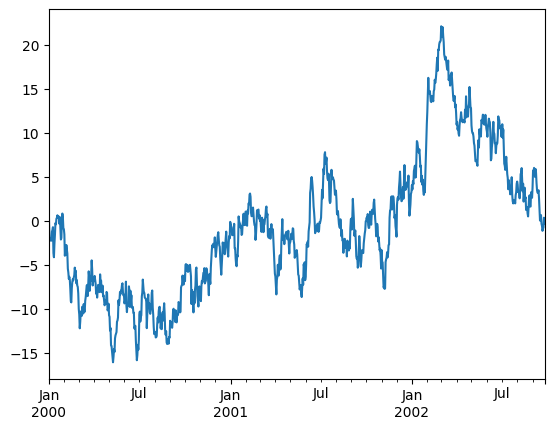

In [77]:
#The plt.close method is used to close a figure window:
ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))
ts = ts.cumsum()
ts.plot()

* Note

When using Jupyter, the plot will appear using plot(). 
Otherwise use matplotlib.pyplot.show to show it or matplotlib.pyplot.savefig to write it to a file.

<Figure size 640x480 with 0 Axes>

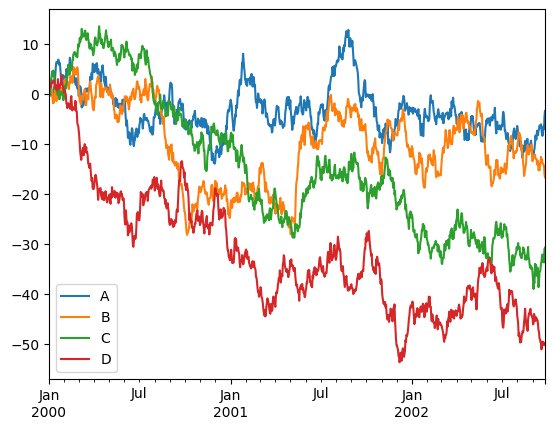

In [78]:
#plot() plots all columns:
df = pd.DataFrame(
    np.random.randn(1000, 4), index=ts.index, columns=["A", "B", "C", "D"]
)
df = df.cumsum()
plt.figure()
df.plot()
plt.legend(loc='best')

# Importing and exporting data
See the IO Tools section.

# CSV

In [79]:
#Writing to a csv file: using DataFrame.to_csv()
df = pd.DataFrame(np.random.randint(0, 5, (10, 5)))
df.to_csv("foo.csv")
#Reading from a csv file: using read_csv()
pd.read_csv("foo.csv")

,Unnamed: 0,0,1,2,3,4
0,0,1,3,3,4,2
1,1,2,3,4,4,4
2,2,1,0,1,4,0
3,3,2,1,0,1,2
4,4,2,0,4,3,0
5,5,1,1,2,2,4
6,6,2,3,2,1,1
7,7,2,2,0,4,2
8,8,2,1,4,2,2
9,9,2,2,3,1,0


In [80]:
df.to_parquet("foo.parquet")
pd.read_parquet("foo.parquet")

,0,1,2,3,4
0,1,3,3,4,2
1,2,3,4,4,4
2,1,0,1,4,0
3,2,1,0,1,2
4,2,0,4,3,0
5,1,1,2,2,4
6,2,3,2,1,1
7,2,2,0,4,2
8,2,1,4,2,2
9,2,2,3,1,0


# Excel
Reading and writing to Excel.

Writing to an excel file using DataFrame.to_excel():

In [81]:
df.to_excel("foo.xlsx", sheet_name="Sheet1")

# Gotchas
If you are attempting to perform a boolean operation on a Series or DataFrame you might see an exception like:

In [82]:
if pd.Series([False, True, False]):
     print("I was true")

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().